In [1]:
import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = "../../../data/shop"


orders = pd.read_csv(
    f"{DATA_DIR}/orders.csv",
    usecols=[
        "order_id",
        "user_id",
        "days_since_prior_order",
    ],
)

order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=[
        "order_id",
        "product_id",
    ],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=[
        "product_id",
        "department_id",
    ],
)

departments = pd.read_csv(
    f"{DATA_DIR}/departments.csv",
    usecols=[
        "department_id",
        "department",
    ],
)


# Identify Produce and Alcohol orders.
department_orders = (
    order_products
    .merge(
        products,
        on="product_id",
    )
    .merge(
        departments,
        on="department_id",
    )
    .query(
        "department in ['produce', 'alcohol']"
    )
    [
        [
            "order_id",
            "department",
        ]
    ]
    .drop_duplicates()
    .merge(
        orders,
        on="order_id",
    )
    .dropna(
        subset=["days_since_prior_order"]
    )
)

In [2]:
flawed_summary = (
    department_orders
    .groupby(
        "department",
        as_index=False,
    )
    .agg(
        order_count=(
            "order_id",
            "nunique",
        ),
        typical_cycle_days=(
            "days_since_prior_order",
            "mean",
        ),
    )
)


print(flawed_summary.round(2))


produce_cycle = flawed_summary.loc[
    flawed_summary["department"].eq("produce"),
    "typical_cycle_days",
].iloc[0]

alcohol_cycle = flawed_summary.loc[
    flawed_summary["department"].eq("alcohol"),
    "typical_cycle_days",
].iloc[0]


shorter_group = (
    "Produce"
    if produce_cycle < alcohol_cycle
    else "Alcohol"
)

difference = abs(
    produce_cycle - alcohol_cycle
)


print(
    f"\nShorter purchasing cycle: {shorter_group}"
)

print(
    f"Difference: {difference:.2f} days"
)

  department  order_count  typical_cycle_days
0    alcohol        77572               10.15
1    produce      2259075               10.62

Shorter purchasing cycle: Alcohol
Difference: 0.47 days


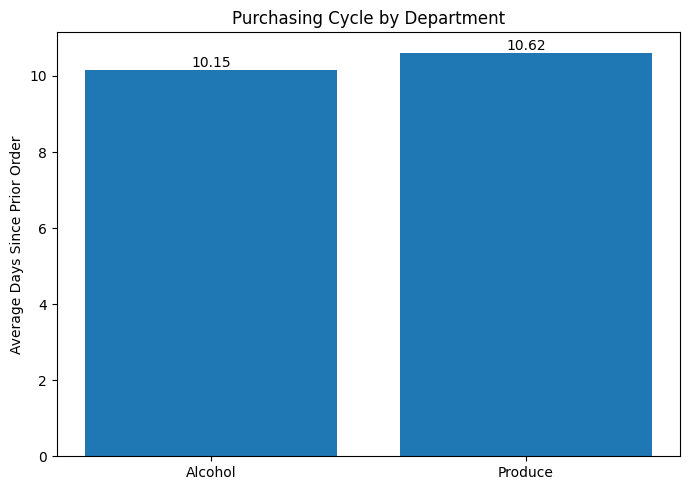

In [3]:
plot_data = flawed_summary.copy()

plot_data["department"] = (
    plot_data["department"]
    .str.title()
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    plot_data["department"],
    plot_data["typical_cycle_days"],
)

ax.set_title(
    "Purchasing Cycle by Department"
)

ax.set_ylabel(
    "Average Days Since Prior Order"
)


for index, value in enumerate(
    plot_data["typical_cycle_days"]
):
    ax.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()